In [20]:
import os, random, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from mtcnn import MTCNN
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import tensorflow as tf

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Configuration ─────────────────────────────────────────
REAL_DIR  = r'c:\Users\Lenovo\Desktop\archive\real_vs_fake\real-vs-fake\train\real'
FAKE_DIR  = r'c:\Users\Lenovo\Desktop\archive\real_vs_fake\real-vs-fake\train\fake'
IMG_SIZE  = 160    
MAX_IMGS  = 2000   
EXTENSIONS = ('.jpg', '.jpeg', '.png')
PROCESSED = r'C:\Users\Lenovo\Desktop\deepshield\data\processed'


print('TensorFlow :', tf.__version__)
print(f'IMG_SIZE   : {IMG_SIZE}×{IMG_SIZE}')
print(f'MAX_IMGS   : {MAX_IMGS} par classe')
print(f'REAL_DIR   : {os.path.abspath(REAL_DIR)}')
print(f'FAKE_DIR   : {os.path.abspath(FAKE_DIR)}')
print(' Config OK')

TensorFlow : 2.20.0
IMG_SIZE   : 160×160
MAX_IMGS   : 2000 par classe
REAL_DIR   : c:\Users\Lenovo\Desktop\archive\real_vs_fake\real-vs-fake\train\real
FAKE_DIR   : c:\Users\Lenovo\Desktop\archive\real_vs_fake\real-vs-fake\train\fake
 Config OK


Images réelles disponibles : 50000
Images fakes disponibles   : 50000


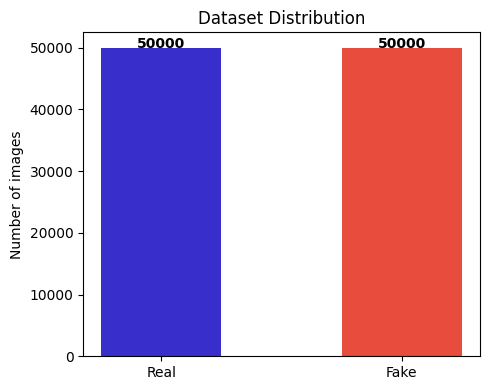

 Dataset OK


In [21]:
real_files = [f for f in os.listdir(REAL_DIR) if f.lower().endswith(EXTENSIONS)]
fake_files = [f for f in os.listdir(FAKE_DIR) if f.lower().endswith(EXTENSIONS)]

print(f'Images réelles disponibles : {len(real_files)}')
print(f'Images fakes disponibles   : {len(fake_files)}')

assert len(real_files) > 0, ' Dossier data/real vide !'
assert len(fake_files) > 0, ' Dossier data/fake vide !'

# Graphe distribution
os.makedirs(r'..\results', exist_ok=True)
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Real', 'Fake'], [len(real_files), len(fake_files)],
               color=["#382ecc", '#e74c3c'], width=0.5)
ax.set_title('Dataset Distribution')
ax.set_ylabel('Number of images')
for bar, val in zip(bars, [len(real_files), len(fake_files)]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30, str(val),
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(r'..\results\distribution_dataset.png', dpi=120)
plt.show()
print(' Dataset OK')

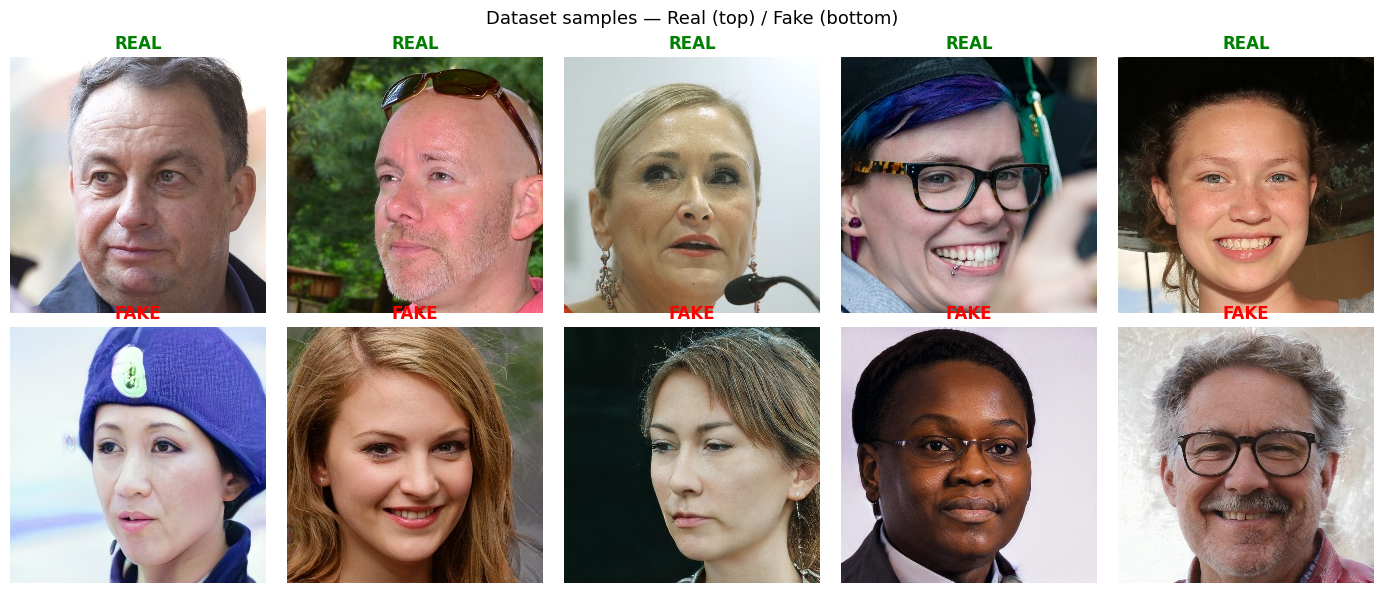

 Exemples sauvegardés dans results/


In [22]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Dataset samples — Real (top) / Fake (bottom)', fontsize=13)

for ax in axes[0]:
    img = cv2.cvtColor(cv2.imread(os.path.join(REAL_DIR, random.choice(real_files))),
                       cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title('REAL', color='green', fontweight='bold'); ax.axis('off')

for ax in axes[1]:
    img = cv2.cvtColor(cv2.imread(os.path.join(FAKE_DIR, random.choice(fake_files))),
                       cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title('FAKE', color='red', fontweight='bold'); ax.axis('off')

plt.tight_layout()
plt.savefig(r'..\results\exemples_dataset.png', dpi=120)
plt.show()
print(' Exemples sauvegardés dans results/')

In [23]:
detector = MTCNN()

def extract_face(image_path, img_size=IMG_SIZE):
    """
    Détecte et extrait le visage principal.
    Retourne un array (img_size, img_size, 3) float32 [0,1] ou None.
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Redimensionner avant MTCNN pour accélérer la détection
        h, w = img_rgb.shape[:2]
        scale = min(1.0, 640 / max(h, w))   # max 640px pour MTCNN
        if scale < 1.0:
            img_small = cv2.resize(img_rgb, (int(w*scale), int(h*scale)))
        else:
            img_small = img_rgb

        faces = detector.detect_faces(img_small)
        if not faces:
            # Fallback : recadrage centré si pas de visage
            face = cv2.resize(img_rgb, (img_size, img_size))
        else:
            best   = max(faces, key=lambda x: x['confidence'])
            x, y, fw, fh = best['box']
            # Remettre à l'échelle originale
            x  = int(x  / scale); y  = int(y  / scale)
            fw = int(fw / scale); fh = int(fh / scale)
            x, y = max(0, x), max(0, y)
            face = img_rgb[y:y+fh, x:x+fw]
            if face.size == 0:
                return None
            face = cv2.resize(face, (img_size, img_size))

        return face.astype('float32') / 255.0

    except Exception:
        return None

# Test rapide
print('Test MTCNN sur 3 images...')
for fname in real_files[:3]:
    result = extract_face(os.path.join(REAL_DIR, fname))
    print(f'  {fname} → {" OK " + str(result.shape) if result is not None else " skipped"}')
print(' MTCNN OK')

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Test MTCNN sur 3 images...
  00000.jpg →  OK (160, 160, 3)
  00002.jpg →  OK (160, 160, 3)
  00003.jpg →  OK (160, 160, 3)
 MTCNN OK


In [24]:
def load_and_extract(folder, label, max_imgs):
    files = [f for f in os.listdir(folder) if f.lower().endswith(EXTENSIONS)]
    random.shuffle(files)
    files = files[:max_imgs]
    X, y, skipped = [], [], 0
    for fname in tqdm(files, desc=f"{'REAL' if label==0 else 'FAKE'}"):
        face = extract_face(os.path.join(folder, fname))
        if face is not None:
            X.append(face); y.append(label)
        else:
            skipped += 1
    print(f'  → Extraites: {len(X)} | Ignorées: {skipped}')
    return X, y

print(' Extraction REAL...')
X_real, y_real = load_and_extract(REAL_DIR, 0, MAX_IMGS)

print('\n Extraction FAKE...')
X_fake, y_fake = load_and_extract(FAKE_DIR, 1, MAX_IMGS)

# Fusion + shuffle
X = np.array(X_real + X_fake, dtype='float32')
y = np.array(y_real + y_fake, dtype='int32')
idx = np.arange(len(X)); np.random.shuffle(idx)
X, y = X[idx], y[idx]

print(f'\n Dataset final : {X.shape}')
print(f'   REAL: {sum(y==0)} | FAKE: {sum(y==1)}') 
print(f'   RAM estimée : {X.nbytes / 1e6:.0f} Mo')

 Extraction REAL...


REAL: 100%|██████████| 2000/2000 [03:31<00:00,  9.46it/s]


  → Extraites: 2000 | Ignorées: 0

 Extraction FAKE...


FAKE: 100%|██████████| 2000/2000 [03:28<00:00,  9.59it/s]


  → Extraites: 2000 | Ignorées: 0

 Dataset final : (4000, 160, 160, 3)
   REAL: 2000 | FAKE: 2000
   RAM estimée : 1229 Mo


In [25]:
# Déjà normalisé [0,1] dans extract_face — vérification
assert X.max() <= 1.0, ' Données non normalisées !'
print(f'Valeurs : min={X.min():.3f}  max={X.max():.3f}  ')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'\nTrain : {X_train.shape[0]} images')
print(f'Val   : {X_val.shape[0]} images')
print(f'Test  : {X_test.shape[0]} images')

for name, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {name} → REAL: {100*sum(y_s==0)/len(y_s):.1f}%  '
          f'FAKE: {100*sum(y_s==1)/len(y_s):.1f}%')
print(' Split OK')

Valeurs : min=0.000  max=1.000  

Train : 2800 images
Val   : 600 images
Test  : 600 images
  Train → REAL: 50.0%  FAKE: 50.0%
  Val → REAL: 50.0%  FAKE: 50.0%
  Test → REAL: 50.0%  FAKE: 50.0%
 Split OK


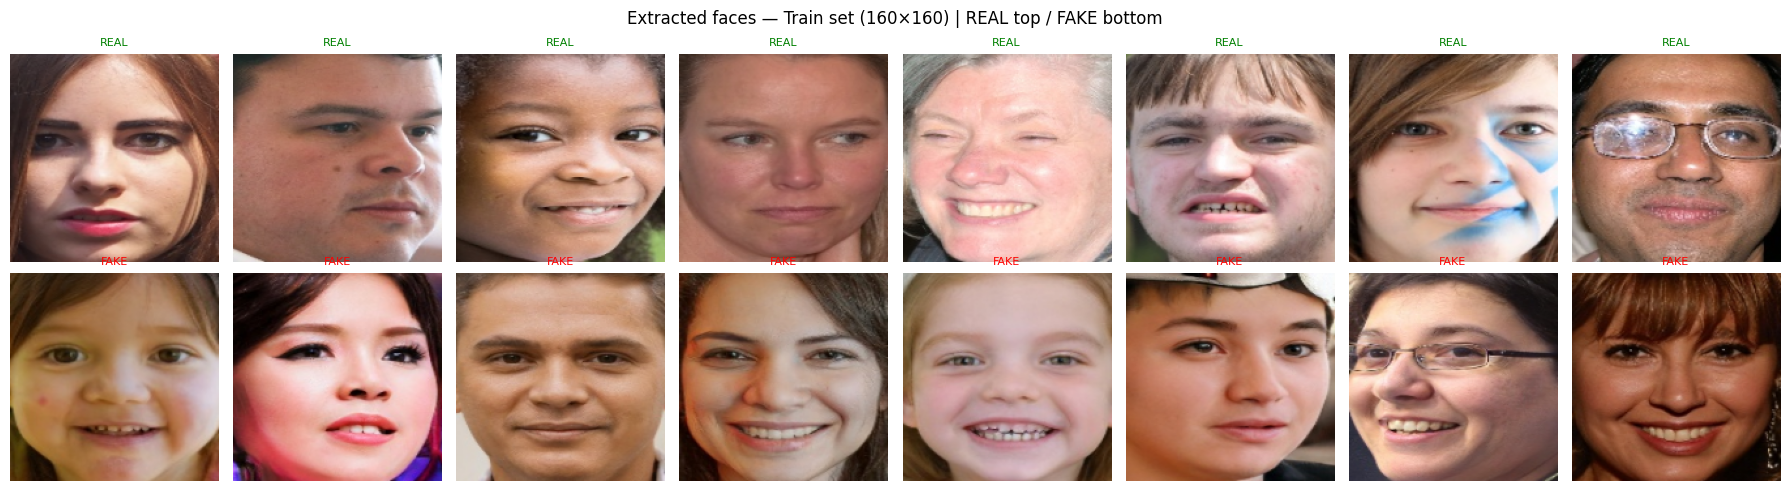

 Visualisation sauvegardée.


In [26]:
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle(f'Extracted faces — Train set ({IMG_SIZE}×{IMG_SIZE}) | REAL top / FAKE bottom', fontsize=12)

real_idx = np.where(y_train == 0)[0][:8]
fake_idx = np.where(y_train == 1)[0][:8]

for i, idx in enumerate(real_idx):
    axes[0][i].imshow(X_train[idx])
    axes[0][i].set_title('REAL', color='green', fontsize=8); axes[0][i].axis('off')

for i, idx in enumerate(fake_idx):
    axes[1][i].imshow(X_train[idx])
    axes[1][i].set_title('FAKE', color='red', fontsize=8); axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(r'..\results\visages_extraits_train.png', dpi=120)
plt.show()
print(' Visualisation sauvegardée.')

In [29]:
PROCESSED = r'C:\Users\Lenovo\Desktop\deepshield\data\processed'
os.makedirs(PROCESSED, exist_ok=True)

saves = {
    'X_train.npy': X_train, 'X_val.npy': X_val, 'X_test.npy': X_test,
    'y_train.npy': y_train, 'y_val.npy': y_val, 'y_test.npy': y_test,
}
for fname, arr in saves.items():
    path = os.path.join(PROCESSED, fname)
    np.save(path, arr)
    print(f'   {fname:15s} → {arr.shape}  ({os.path.getsize(path)/1e6:.1f} Mo)')

# Sauvegarder la config pour les notebooks suivants
config = {'IMG_SIZE': IMG_SIZE, 'MAX_IMGS': MAX_IMGS,
          'n_train': len(X_train), 'n_val': len(X_val), 'n_test': len(X_test)}
import json
with open(os.path.join(PROCESSED, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'\n Notebook 1 terminé !')
print(f'    Prochain : 02_model_training.ipynb')

   X_train.npy     → (2800, 160, 160, 3)  (860.2 Mo)
   X_val.npy       → (600, 160, 160, 3)  (184.3 Mo)
   X_test.npy      → (600, 160, 160, 3)  (184.3 Mo)
   y_train.npy     → (2800,)  (0.0 Mo)
   y_val.npy       → (600,)  (0.0 Mo)
   y_test.npy      → (600,)  (0.0 Mo)

 Notebook 1 terminé !
    Prochain : 02_model_training.ipynb
